# Assigment 4

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

In [2]:
input_path = os.path.join(os.getcwd(), "A04_files")

## Task 1: Implement Hough Transform to detect the lines in the given image as follows

## a.

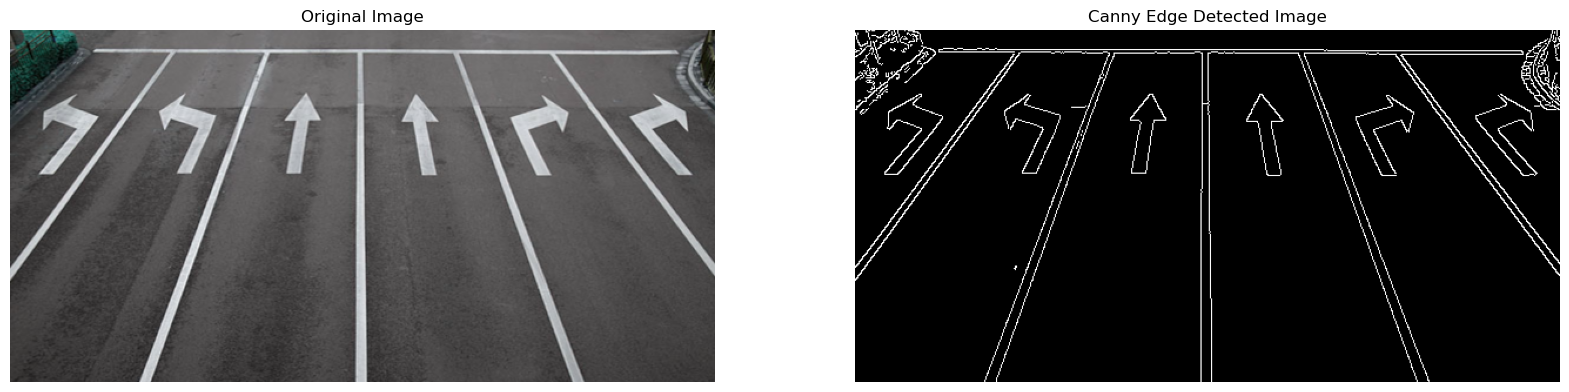

In [3]:
A04_img1 = cv2.imread(os.path.join(input_path, "A04_img1.png"))
A04_img1_canny = cv2.Canny(A04_img1, 100, 200)
fig, axes = plt.subplots(1, 2, figsize=(20,40))
axes[0].imshow(A04_img1)
axes[0].set_title("Original Image")
axes[0].axis('off')
axes[1].imshow(A04_img1_canny, cmap='gray')
axes[1].set_title("Canny Edge Detected Image")
axes[1].axis('off')
plt.show()

## b.

In [4]:
A04_img1_canny.shape

(300, 600)

In [5]:
import math
D_max = math.ceil(math.sqrt((A04_img1.shape[1]**2 + A04_img1.shape[0]**2)))
accumulator_matrix = np.zeros(shape=(D_max*2, 181), dtype=int)
thetas = np.arange(-90, 90+1)
rhos = np.arange(-D_max, D_max+1)

In [6]:
for x in range(A04_img1_canny.shape[1]):
    for y in range(A04_img1_canny.shape[0]):
        if A04_img1_canny[y][x] == 255:
           for theta in thetas:
               r = int(x*np.cos((np.pi/180)*theta) + y*np.sin((np.pi/180)*theta))
               accumulator_matrix[r + D_max][theta+90] += 1

## c.

Text(0.5, 1.0, 'Hough Transform Accumulator Matrix')

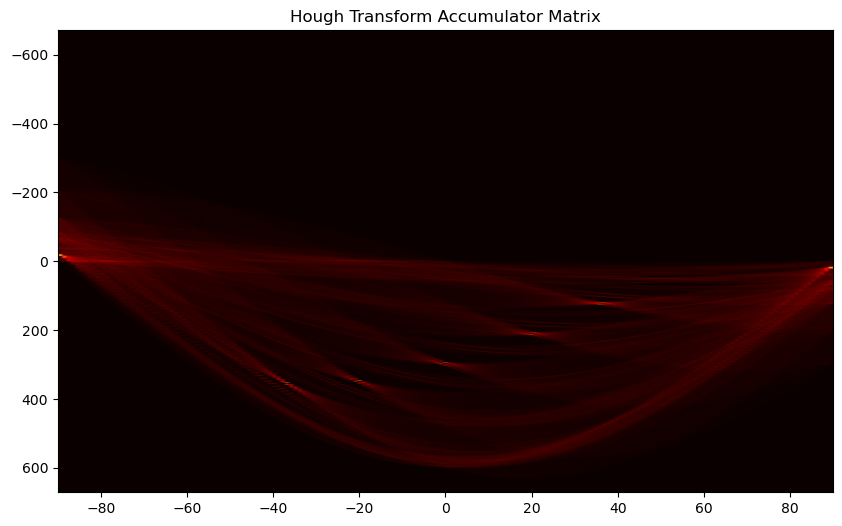

In [7]:
fig, axis = plt.subplots(figsize=(10, 6))
axis.imshow(accumulator_matrix, cmap='hot', aspect='auto', extent=[thetas[0], thetas[-1], rhos[-1], rhos[0]])
axis.set_title("Hough Transform Accumulator Matrix")

## d.

In [8]:
np.unique_counts(accumulator_matrix)

UniqueCountsResult(values=array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  84,  85,  86,  87,  88,  89,  90,  91,  92,
        93,  94,  95,  97,  99, 100, 102, 104, 105, 106, 108, 110, 115,
       116, 118, 119, 120, 121, 123, 124, 130, 131, 134, 135, 136, 139,
       140, 141, 142, 143, 153, 156, 157, 159, 162, 163, 165, 168, 170,
       175, 183, 194, 202, 226, 240, 241, 327, 330]), counts=array([146436,    888,   5364,   3550,   4829,   4832,   6039,   5298,
         5306,   5228,   5063,   4626,   4520,   4227,   4035,   3720,
         3418,   3134,   2688,   2426,   2109,   18

In [9]:
threshold = 150
line_overlay = np.zeros(shape=(A04_img1.shape[0], A04_img1.shape[1]), dtype=int)
max_length_line = 0

for rho in range(accumulator_matrix.shape[0]):
    for theta in range(accumulator_matrix.shape[1]):
        if accumulator_matrix[rho][theta] >= threshold:
            x1, x2, y1, y2 = -1, -1, -1, -1
            for x in range(A04_img1.shape[1]):
                if theta-90 == 0:
                    max_length_line = max(max_length_line, A04_img1.shape[1])
                    for i in range(A04_img1.shape[0]):
                        line_overlay[i][rho-D_max] = 1
                    continue
                else:
                    y = int(((rho-D_max) - x*np.cos((theta-90)*(np.pi/180)))/np.sin((theta-90)*(np.pi/180)))
                if y >= 0 and y < A04_img1.shape[0]:
                    line_overlay[y][x] = 1
                    if x1 == -1:
                        x1, y1 = x, y
                    x2, y2 = x, y

            line_length = math.sqrt((x1-x2)**2 + (y1-y2)**2)
            max_length_line = max(max_length_line, line_length)

In [10]:
line_overlay_colored = np.zeros_like(A04_img1)
line_overlay_colored[:, :, 0] = line_overlay * 255 
A04_img1_overlay = cv2.add(line_overlay_colored, A04_img1)

## e.

Length of longest detected line: 600


Text(0.5, 1.0, 'Overlayed Image')

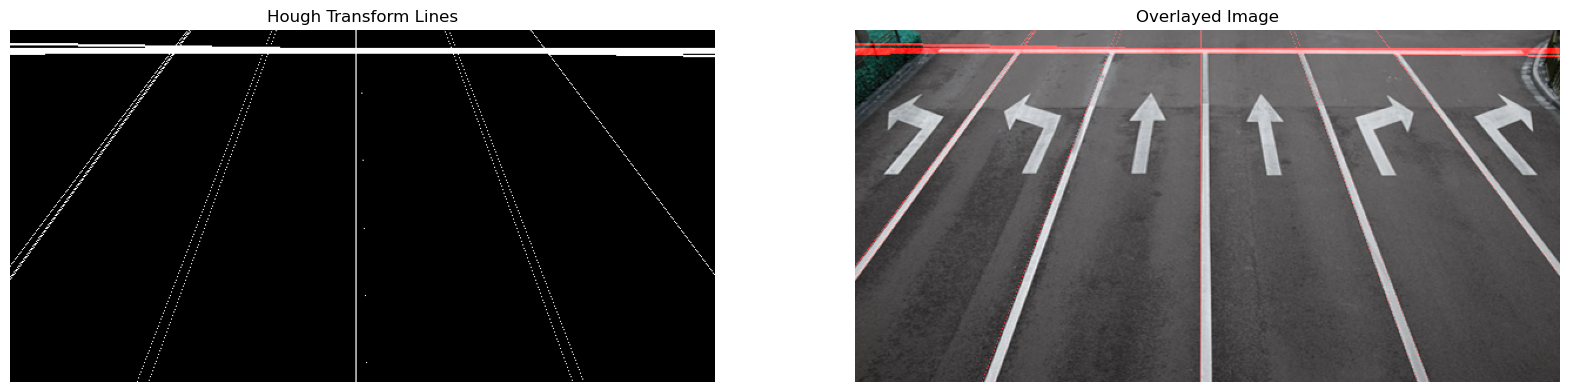

In [11]:
print(f"Length of longest detected line: {max_length_line}")
fig, axis = plt.subplots(1, 2, figsize=(20,40))
axis[0].imshow(line_overlay, cmap='gray')
axis[0].axis('off')
axis[0].set_title("Hough Transform Lines")
axis[1].imshow(A04_img1_overlay, cmap='gray')
axis[1].axis('off')
axis[1].set_title("Overlayed Image")

## f.

In [12]:
lines = cv2.HoughLines(A04_img1_canny, 1, np.pi/180, 150, None, 0, 0)
A04_img1_overlay_cv2 = A04_img1.copy()
line_length = []
max_length_line = 0

if lines is not None:
    for i in range(0, len(lines)):
        rho = lines[i][0][0]
        theta = lines[i][0][1]
        a = math.cos(theta)
        b = math.sin(theta)
        x0 = a * rho
        y0 = b * rho
        pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
        pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
        cv2.line(A04_img1_overlay_cv2, pt1, pt2, (255,0,0), 1, cv2.LINE_AA)

        # Length calculation
        # Point1
        if theta == 0:
            line_length.append(A04_img1.shape[0])
            continue
        elif theta == np.pi/2:
            line_length.append(A04_img1.shape[1])
        x1, x2, y1, y2 = None, None, None, None
        y1 = int((rho - 0*a)/b)
        if 0 <= y1 < A04_img1.shape[0]:
            x1 = 0
        else:
            if theta < np.pi/2:
                y1 = A04_img1.shape[0]-1
            else:
                y1 = 0
            x1 = int((rho - y1*b)/a)

        # Point2
        y2 = int((rho - (A04_img1.shape[1]-1)*a)/b)
        if 0 <= y2 < A04_img1.shape[0]:
            x2 = A04_img1.shape[1]-1
        else:
            if theta < np.pi/2:
                y2 = A04_img1.shape[1]
            else:
                y2 = 0
            x2 = int((rho - y2*b)/a)
        length = math.sqrt((x1-x2)**2 + (y1-y2)**2)
        if length > max_length_line:
            max_length_line = length
            cv2.line(A04_img1_overlay_cv2, pt1, pt2, (0,i*50,255), 1, cv2.LINE_AA)
            cv2.circle(A04_img1_overlay_cv2, (x1,y1), 3, (255, 0, 0), -1)
            cv2.circle(A04_img1_overlay_cv2, (x2,y2), 3, (0, 255, 0), -1)
        line_length.append(math.sqrt((x1-x2)**2 + (y1-y2)**2))

Length of longest detected line: 600.0


Text(0.5, 1.0, 'Overlayed Image OpenCV')

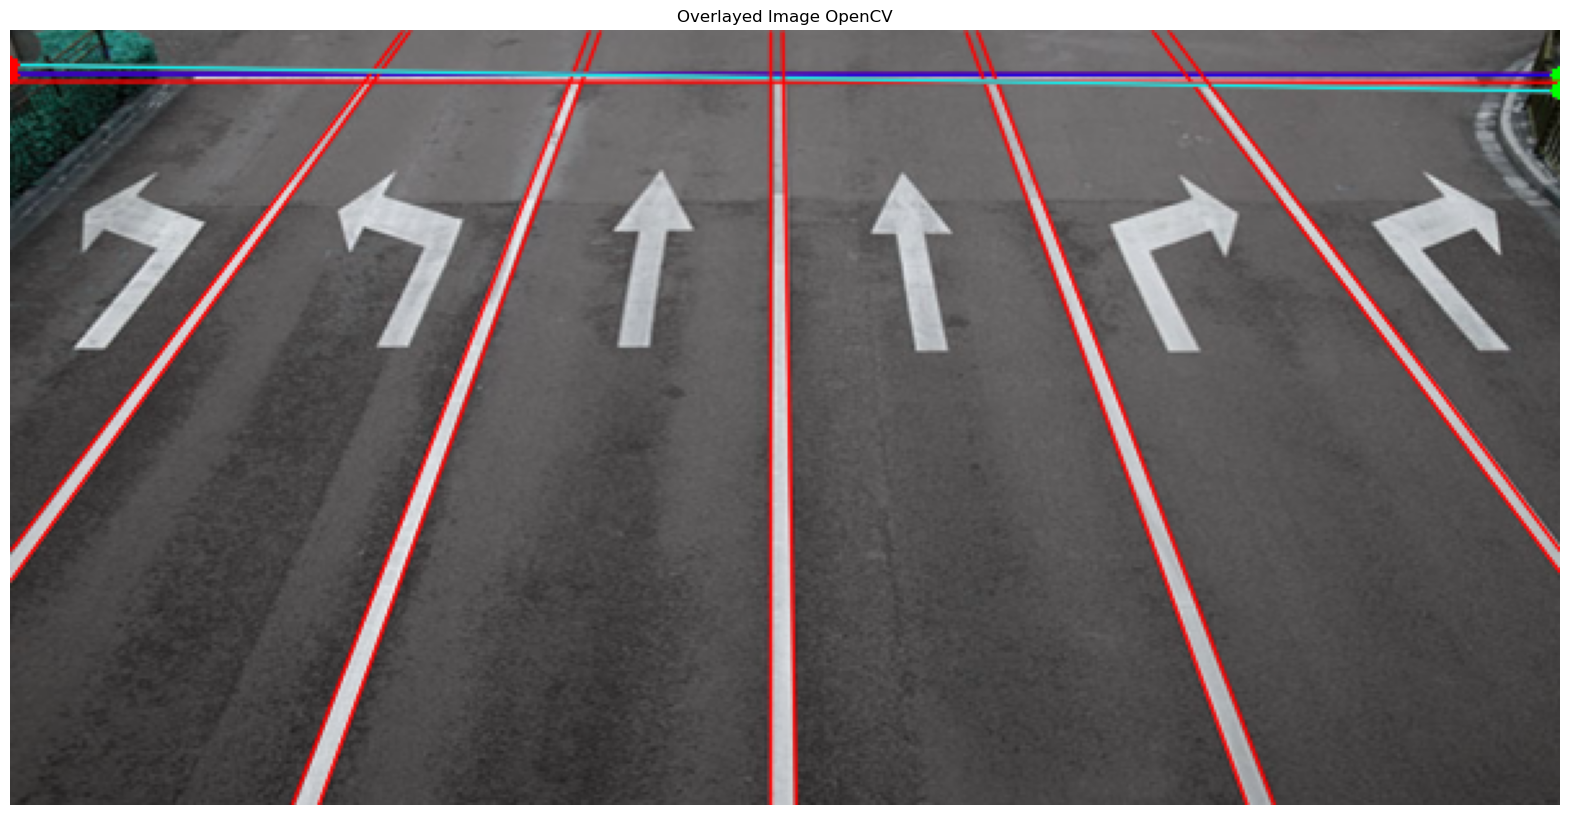

In [13]:
print(f"Length of longest detected line: {np.max(line_length)}")
fig, axis = plt.subplots(figsize=(20,40))
axis.imshow(A04_img1_overlay_cv2, cmap='gray')
axis.axis('off')
axis.set_title("Overlayed Image OpenCV")

## Task 2: Land cover classification using GLCM

In [94]:
data_set_dir = os.path.join(os.getcwd(), "A04_files", "UCMerced_LandUse", "Images")

train_images, val_images, test_images = [], [], []
train_images_label, val_images_label, test_images_label = [], [], []
train_images_name, val_images_name, test_images_name = [], [], []

for dir in sorted(os.listdir(data_set_dir)):
    label = dir
    image_dir = os.path.join(data_set_dir, dir)
    images = sorted(os.listdir(image_dir))

    for image in images[:int(len(images)*(0.7))]:
        img = cv2.imread(os.path.join(image_dir, image))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        train_images.append(img)
        train_images_label.append(label)
        train_images_name.append(image)

    for image in images[int(len(images)*(0.7)):int(len(images)*(0.85))]:
        img = cv2.imread(os.path.join(image_dir, image))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        val_images.append(img)
        val_images_label.append(label)
        val_images_name.append(image)

    for image in images[int(len(images)*(0.85)):len(images)]:
        img = cv2.imread(os.path.join(image_dir, image))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        test_images.append(img)
        test_images_label.append(label)
        test_images_name.append(image)

dataset_train = pd.DataFrame(data={"name": train_images_name, "image": train_images, "label": train_images_label})
dataset_val   = pd.DataFrame(data={"name": val_images_name, "image": val_images, "label": val_images_label})
dataset_test  = pd.DataFrame(data={"name": test_images_name, "image": test_images, "label": test_images_label})

,name,image,label
70,airplane00.tif,"[[213, 215, 212, 210, 213, 214, 213, 219, 211,...",airplane
71,airplane01.tif,"[[124, 127, 129, 133, 136, 120, 116, 119, 123,...",airplane
72,airplane02.tif,"[[124, 127, 129, 133, 136, 120, 116, 119, 123,...",airplane
73,airplane03.tif,"[[204, 202, 197, 193, 194, 197, 194, 191, 194,...",airplane
74,airplane04.tif,"[[114, 140, 124, 122, 158, 185, 191, 183, 182,...",airplane
...,...,...,...
135,airplane65.tif,"[[137, 161, 171, 168, 165, 165, 165, 156, 158,...",airplane
136,airplane66.tif,"[[236, 225, 172, 136, 133, 141, 143, 140, 136,...",airplane
137,airplane67.tif,"[[161, 163, 159, 166, 176, 189, 177, 172, 178,...",airplane
138,airplane68.tif,"[[188, 191, 198, 203, 205, 203, 194, 194, 188,...",airplane
